# Exploratory EDA Overview

Notebook nay gop cac phan EDA tong quan truoc day nam trong nhom script `src/eda_01_overview.py` den `src/eda_05_time_heatmap.py`.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

DATA_DIR = Path("../../data/processed/clean_full")
FIG_DIR = Path("../../reports/figures/overview")
FIG_DIR.mkdir(parents=True, exist_ok=True)
DAY_LABELS = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]


In [2]:
cols = [
    "YEAR", "ARR_DEL15", "CANCELLED", "DIVERTED", "OP_CARRIER", "ORIGIN", "DEST", "ROUTE",
    "ARR_DELAY_NEW", "DEP_TIME_BLK", "DAY_OF_WEEK"
]
df = pd.read_parquet(DATA_DIR, engine="pyarrow", columns=cols)
df["ARR_DEL15"] = pd.to_numeric(df["ARR_DEL15"], errors="coerce").astype("float64")
df["CANCELLED"] = pd.to_numeric(df["CANCELLED"], errors="coerce").fillna(0).astype("float64")
df["DIVERTED"] = pd.to_numeric(df["DIVERTED"], errors="coerce").fillna(0).astype("float64")
df["ARR_DELAY_NEW"] = pd.to_numeric(df["ARR_DELAY_NEW"], errors="coerce").astype("float64")
df["DAY_OF_WEEK"] = pd.to_numeric(df["DAY_OF_WEEK"], errors="coerce").astype("Int64")
df["operational_issue"] = ((df["ARR_DEL15"] == 1) | (df["CANCELLED"] == 1) | (df["DIVERTED"] == 1)).astype("int64")
df["operational_otp"] = 1 - df["operational_issue"]
df.head()


,YEAR,ARR_DEL15,OP_CARRIER,ORIGIN,DEST,ROUTE,ARR_DELAY_NEW,DEP_TIME_BLK,DAY_OF_WEEK
0,2021,1.0,9E,ATL,JAN,ATL-JAN,249.0,1000-1059,4
1,2021,1.0,9E,JAN,ATL,JAN-ATL,218.0,1100-1159,4
2,2021,0.0,9E,ATL,GSP,ATL-GSP,7.0,2000-2059,4
3,2021,1.0,9E,OKC,ATL,OKC-ATL,238.0,0600-0659,4
4,2021,0.0,9E,BHM,ATL,BHM-ATL,0.0,1500-1559,4


## Tong quan OTP van hanh

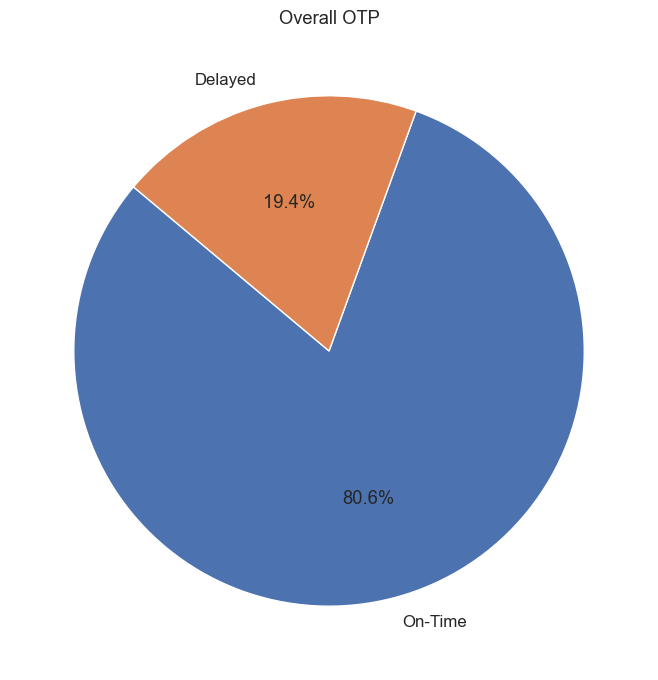

C:\Users\Admin\AppData\Local\Temp\ipykernel_1228\2409173753.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly = df.groupby("YEAR")["ARR_DEL15"].mean().reset_index(name="delay_rate")


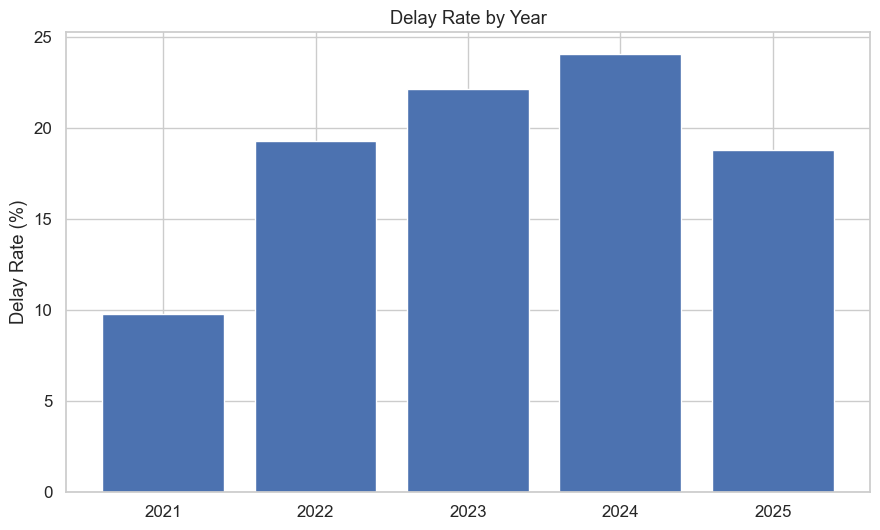

In [3]:
on_time = df["operational_otp"].sum()
issue = df["operational_issue"].sum()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie([on_time, issue], labels=["Dung gio van hanh", "Su co van hanh"], autopct="%1.1f%%", startangle=140)
ax.set_title("Tong quan OTP van hanh")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_operational_otp_pie_chart.png", dpi=180, bbox_inches="tight")
plt.show()

yearly = df.groupby("YEAR")["operational_otp"].mean().reset_index(name="otp_rate")
yearly["otp_pct"] = yearly["otp_rate"] * 100
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(yearly["YEAR"].astype(str), yearly["otp_pct"])
ax.set_title("OTP van hanh theo nam")
ax.set_ylabel("OTP van hanh (%)")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_operational_otp_by_year.png", dpi=180, bbox_inches="tight")
plt.show()


## OTP van hanh theo hang bay

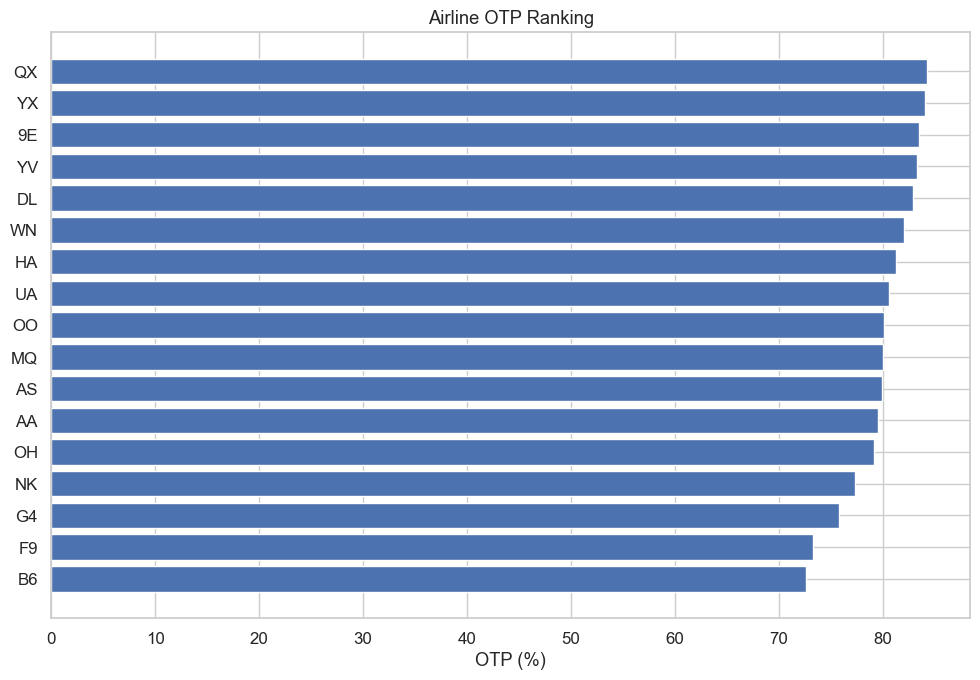

C:\Users\Admin\AppData\Local\Temp\ipykernel_1228\2933761208.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["YEAR", "OP_CARRIER"])["ARR_DEL15"]


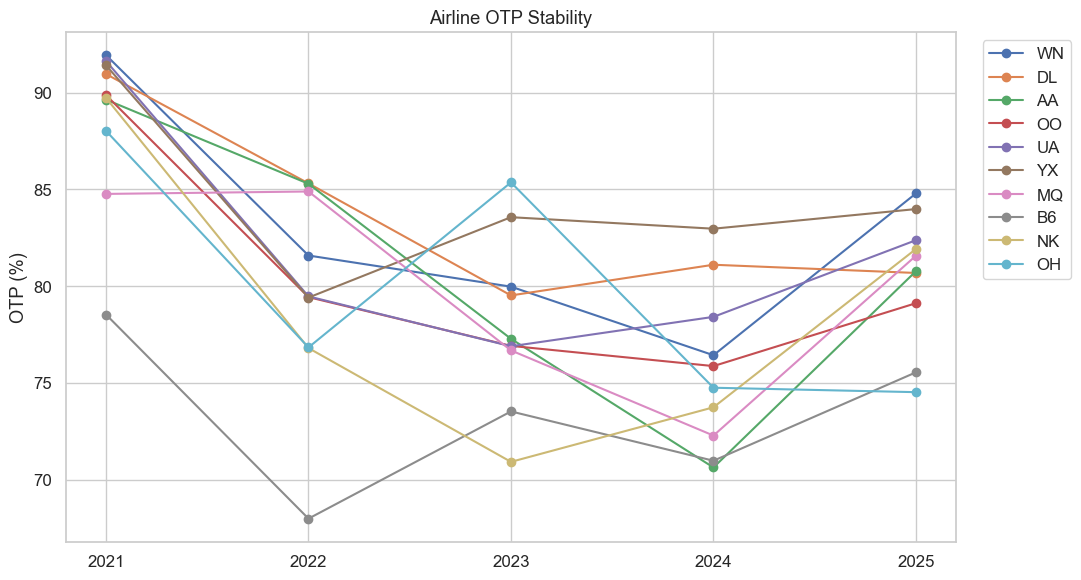

In [4]:
carrier_otp = (
    df.groupby("OP_CARRIER")["operational_otp"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "otp_rate", "count": "flights"})
)
carrier_otp["otp_pct"] = carrier_otp["otp_rate"] * 100
carrier_otp = carrier_otp.sort_values("otp_pct")

fig, ax = plt.subplots(figsize=(10, max(7, len(carrier_otp) * 0.4)))
ax.barh(carrier_otp["OP_CARRIER"], carrier_otp["otp_pct"])
ax.set_title("Xep hang OTP van hanh theo hang bay")
ax.set_xlabel("OTP (%)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_airline_operational_otp_ranking.png", dpi=180, bbox_inches="tight")
plt.show()

yearly_carrier = (
    df.groupby(["YEAR", "OP_CARRIER"])["operational_otp"]
    .mean()
    .reset_index(name="otp_rate")
)
yearly_carrier["otp_pct"] = yearly_carrier["otp_rate"] * 100
top_carriers = df["OP_CARRIER"].value_counts().head(10).index.tolist()

fig, ax = plt.subplots(figsize=(11, 6))
for carrier in top_carriers:
    sub = yearly_carrier[yearly_carrier["OP_CARRIER"] == carrier].sort_values("YEAR")
    ax.plot(sub["YEAR"].astype(str), sub["otp_pct"], marker="o", label=carrier)
ax.set_title("Do on dinh OTP van hanh theo hang bay")
ax.set_ylabel("OTP (%)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_airline_operational_otp_stability.png", dpi=180, bbox_inches="tight")
plt.show()


## OTP van hanh theo san bay

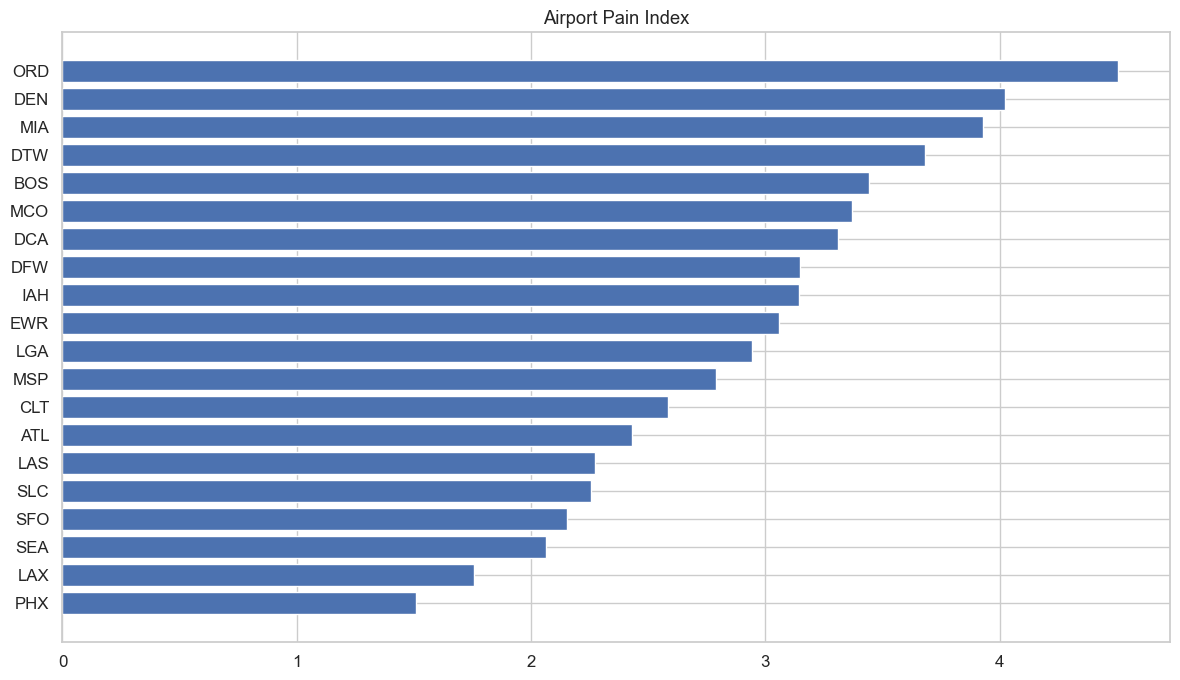

In [5]:
top_airports = df["ORIGIN"].value_counts().head(20).index
sub = df[df["ORIGIN"].isin(top_airports)].copy()
agg = (
    sub.groupby("ORIGIN")
    .agg(
        flights=("operational_otp", "count"),
        otp_rate=("operational_otp", "mean"),
    )
    .reset_index()
)
agg["otp_pct"] = agg["otp_rate"] * 100
agg = agg.sort_values("otp_pct", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(agg["ORIGIN"], agg["otp_pct"])
ax.invert_yaxis()
ax.set_title("Xep hang OTP van hanh theo san bay")
ax.set_xlabel("OTP (%)")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_airport_operational_otp_ranking.png", dpi=180, bbox_inches="tight")
plt.show()


## OTP van hanh theo tuyen bay

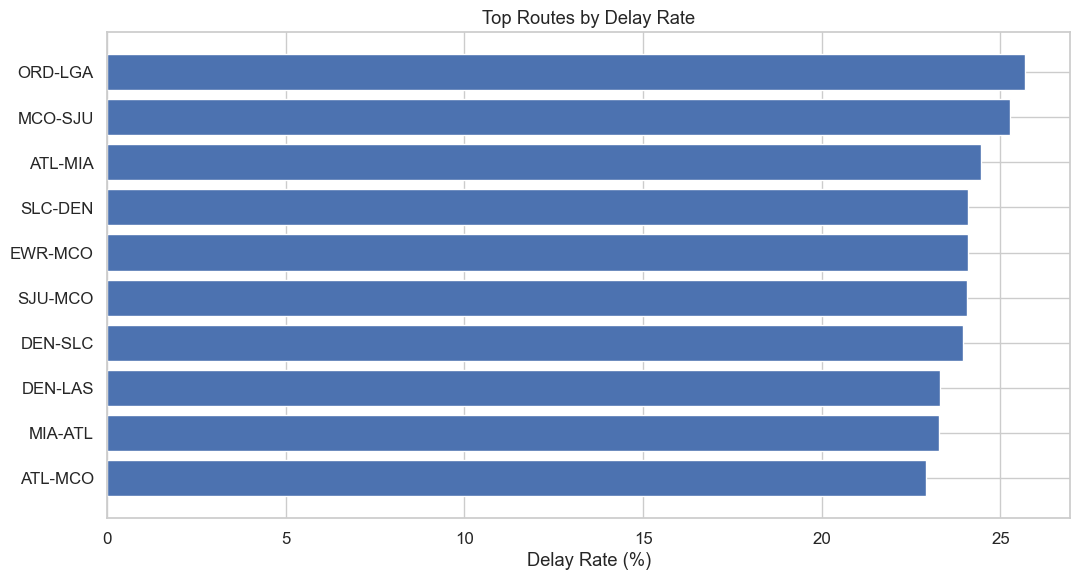

In [6]:
route_stats = (
    df.groupby("ROUTE")["operational_otp"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={"count": "volume", "mean": "otp_rate"})
)
route_stats["otp_pct"] = route_stats["otp_rate"] * 100
top_vol = route_stats.nlargest(50, "volume")
best = top_vol.nlargest(10, "otp_pct").sort_values("otp_pct")

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(best["ROUTE"], best["otp_pct"])
ax.set_title("Top tuyen bay co OTP van hanh cao nhat")
ax.set_xlabel("OTP (%)")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_top_routes_operational_otp.png", dpi=180, bbox_inches="tight")
plt.show()


## Heatmap dung gio van hanh

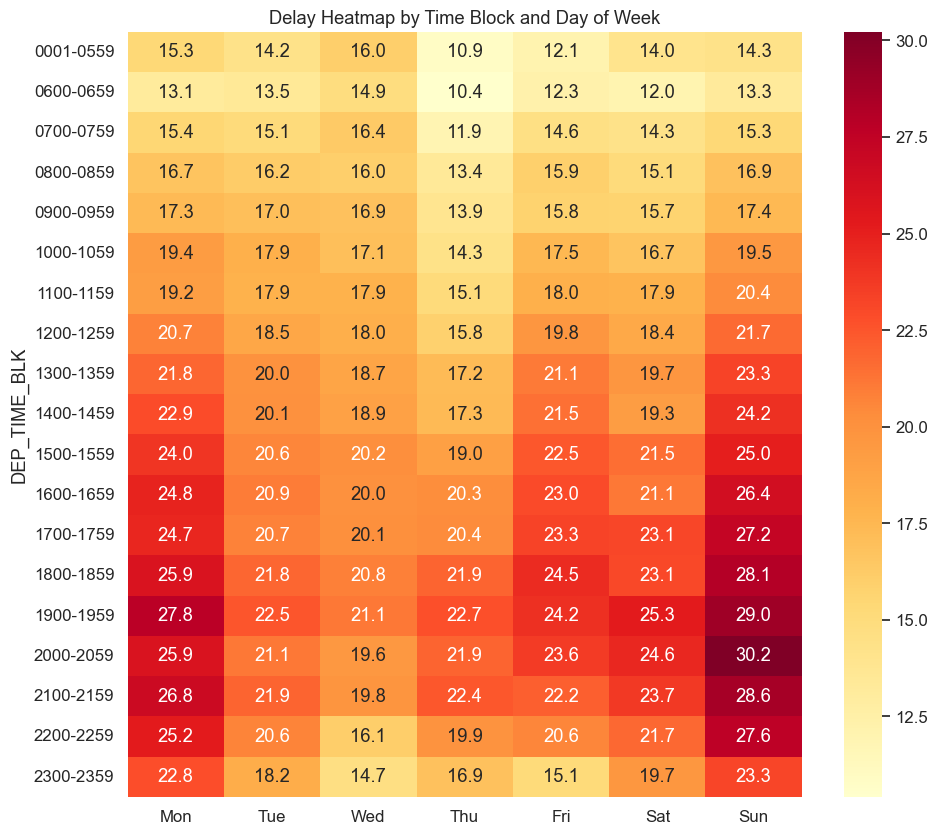

In [7]:
pivot = df.pivot_table(index="DEP_TIME_BLK", columns="DAY_OF_WEEK", values="operational_otp", aggfunc="mean").sort_index()
pivot = pivot.reindex(columns=range(7))
pivot = pivot.apply(pd.to_numeric, errors="coerce").astype("float64")
pivot.columns = DAY_LABELS

fig, ax = plt.subplots(figsize=(10, max(8, len(pivot) * 0.45)))
sns.heatmap(pivot.mul(100), annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Heatmap dung gio van hanh theo khung gio va thu trong tuan")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_operational_otp_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
